In [8]:
%reset -f
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def liter_per_minute_to_kg_per_s(lpm):
    """Convert flow rate from liters per minute to kg per second."""
    return (lpm * 1e-3) / 60.0 * 1000.0  # assuming water density ~1000 kg/m^3

Mass of each cell: 0.05 kg


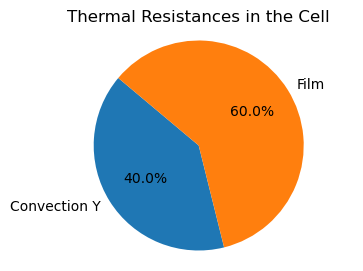

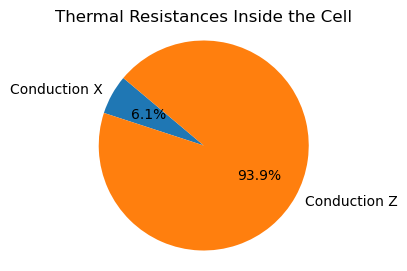

In [9]:
# --- Constants ---
length = 0.270  # cell length in x [m]
height = 0.106  # cell height in z [m]
thickness = 0.0248  # cell thickness in y [m]
s_film = 1e-3  # film thickness [m] (0.1 mm)
volume = length * height * thickness  # cell volume [m^3]

# Discretization parameters
nx = 20 # discretization in x
nz = 2  # discretization in z
ny = 1 # discretization in y (1D simplification, use 1 for now)
dx = length / nx
dz = height / nz
dy = thickness / ny
dV = dx * dy * dz  # volume of each cell [m^3]

# Coolant properties
cp_fluid = 4186  # water [J/kg·K]
flow_rate = liter_per_minute_to_kg_per_s(0.29)  # flow rate [kg/s] (1 L/min)

# Boundary and initial conditions
T_init = 25  # Initial temperature [C]
T_fluid_in = 25  # Coolant inlet temperature [C]
h_conv = 300.0  # Convective heat transfer coefficient [W/m^2·K]

# Material properties
k_cell_x = 30.0         # thermal conductivity of cell in the plane x-z [W/m·K]
k_cell_z = 30.0         # thermal conductivity of cell in the plane x-z [W/m·K]
k_film = 0.2           # thermal conductivity of film [W/m·K] 

rho_cell = 2700.0    # density [kg/m^3] (Close to bulk Aluminum)
m_cell = rho_cell * dV  # mass of each cell [kg]
print(f"Mass of each cell: {m_cell:.2f} kg")
cp_cell = 897.0      # specific heat [J/kg·K] (Close to bulk Aluminum)
#alpha = k_cell_x / (rho_cell * cp_cell)  # thermal conductivity [m^2/s]

Rth_cond_x = dx / (k_cell_x*dz*dy)  # thermal resistance in x direction [K/W]
Rth_cond_z = dz / (k_cell_z*dx*dy)  # thermal resistance in x direction [K/W]
Rth_conv_y = 1/(h_conv * dx * dz)  # thermal resistance in y direction [K/W]
Rth_film = s_film/(k_film * dz * dx)  # thermal resistance of film [K/W]

#Pie chart of the resistances
resistances_y = {
    'Convection Y': Rth_conv_y,
    'Film': Rth_film
}
plt.figure(figsize=(4, 3))
plt.pie(resistances_y.values(), labels=resistances_y.keys(), autopct='%1.1f%%', startangle=140)
plt.title('Thermal Resistances in the Cell')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

resistances_inside = {
    'Conduction X': Rth_cond_x,
    'Conduction Z': Rth_cond_z
}

plt.figure(figsize=(4, 3))
plt.pie(resistances_inside.values(), labels=resistances_inside.keys(), autopct='%1.1f%%', startangle=140)
plt.title('Thermal Resistances Inside the Cell')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


In [10]:
# Time setup
dt = 0.1  # time step [s]
t_end = 3000  # total time [s]
nt = int(t_end / dt)


Q_tot = 60 # Total heat generation [W]
q_gen = Q_tot/volume # Heat generation [W/m^3]
print(f"Heat generation per unit volume: {q_gen:.2f} W/m^3")

# Cross-sectional area for convection (1D simplification)
A_conv = dz * dx  # 1m depth assumed

# --- Initialize temperature field ---
T = np.ones((nz, nx)) * T_init

# --- Functions ---
def conduction_term(T, i, j):
    term_x = 0
    q_out_x = 0
    if j > 0: # Is not the first column
        term_x = (T[i, j-1] - T[i, j])
        q_out_x += term_x /Rth_cond_x #Heat flow to the previous (left) cell in x direction
        #update temperature of the previous cell
        dT_cell = (term_x /Rth_cond_x)/(m_cell * cp_cell)  # Temperature change in the previous cell
        T[i, j-1] += dT_cell
    if j < nx-1: # Is not the last column
        term_x = (T[i, j+1] - T[i, j]) # Heat flow to the next (right) cell in x direction
        q_out_x += term_x / Rth_cond_x
        #update temperature of the next cell
        dT_cell = (term_x / Rth_cond_x)/(m_cell * cp_cell)
        T[i, j+1] += dT_cell
    
    q_out_z = 0
    if i > 0: # Is not the first row
        term_z = (T[i-1, j] - T[i, j])
        q_out_z += term_z / Rth_cond_z  
        # update temperature of the above cell
        dT_cell = (term_z / Rth_cond_z)/(m_cell * cp_cell)
        T[i-1, j] += dT_cell

    if i < nz-1: # Is not the last row
        term_z = (T[i+1, j] - T[i, j])
        q_out_z += term_z / Rth_cond_z  
        # update temperature of the below cell
        dT_cell = (term_z / Rth_cond_z)/(m_cell * cp_cell)
        T[i+1, j] += dT_cell
    
    q_out_conductive = q_out_x + q_out_z
    return q_out_conductive

def convection_loss(T_cell, T_fluid):
    q_conv = (T_cell - T_fluid)/(Rth_conv_y + Rth_film)
    return  q_conv


def update_fluid_temp(T_fluid, q_conv, flow_rate, cp_fluid):
    # m_dot * cp * dT = q_conv  => dT = q_conv / (m_dot * cp)
    m_dot = flow_rate  # [kg/s]
    dT_fluid = q_conv / (m_dot * cp_fluid)

    return T_fluid + dT_fluid



# Store temperature history
T_hist = np.zeros((nt, nz, nx))

# --- Time loop ---
T_fluid_top = np.ones(nx) * T_fluid_in
T_fluid_bottom = np.ones(nx) * T_fluid_in

for t in range(nt):
    T_new = T.copy()
    Q_cond = np.zeros_like(T)  # net conduction gain/loss per cell
    
    for i in range(nz):
        for j in range(nx-1):
            dT = T[i, j+1] - T[i, j]  # Temperature difference in x direction
            q = dT / Rth_cond_x  # Heat flow from jto j+1

            #Energy distribution (what dissipate j, is recived by j+1)
            Q_cond[i,j] = Q_cond[i,j] + q
            Q_cond[i,j+1] = Q_cond[i,j+1] - q

        # Conduction in the z direction
    for i in range(nz - 1):
        for j in range(nx):
            dT = T[i+1, j] - T[i, j]
            q = dT / Rth_cond_z #Heat flow from i to i+1

            Q_cond[i, j] += q
            Q_cond[i+1, j] -= q

        #Update temperature (first row first)
        for j in range(nx):
            conv_therm = convection_loss(T[0, j], T_fluid_top[j])
            Q_gen_cell = q_gen * dV  # Heat generation in the cell [W]
            
            Q_net = Q_gen_cell - conv_therm + Q_cond[0, j]  # Net heat in the cell
            dT = dt * Q_net / (m_cell * cp_cell)  # Temperature change in the cell
            T_new[0, j] += dT

            # Update fluid temperature at the top
            if j< nx-1:  # Avoid index out of bounds
                T_fluid_top[j+1] = update_fluid_temp(T_fluid_top[j], conv_therm, flow_rate, cp_fluid)
        
        # Boundary of u turn, bottom inlet is top outlet
        T_fluid_bottom[-1] = T_fluid_top[-1]  # Bottom fluid temperature is the same as the top fluid temperature at the end of the row

        #Update temeprature bottom raw
        for j in reversed(range(nx)):
            conv_therm = convection_loss(T[1, j], T_fluid_bottom[j])
            Q_gen_cell = q_gen * dV
            Q_net = Q_gen_cell - conv_therm + Q_cond[1, j]

            dT = dt * Q_net / (m_cell * cp_cell)
            T_new[1, j] += dT

            # Update fluid temperature at the bottom
            if j > 0:
                T_fluid_bottom[j-1] = update_fluid_temp(T_fluid_bottom[j], conv_therm, flow_rate, cp_fluid)

    
    T = T_new.copy()
    T_hist[t] = T
    

Heat generation per unit volume: 84533.71 W/m^3


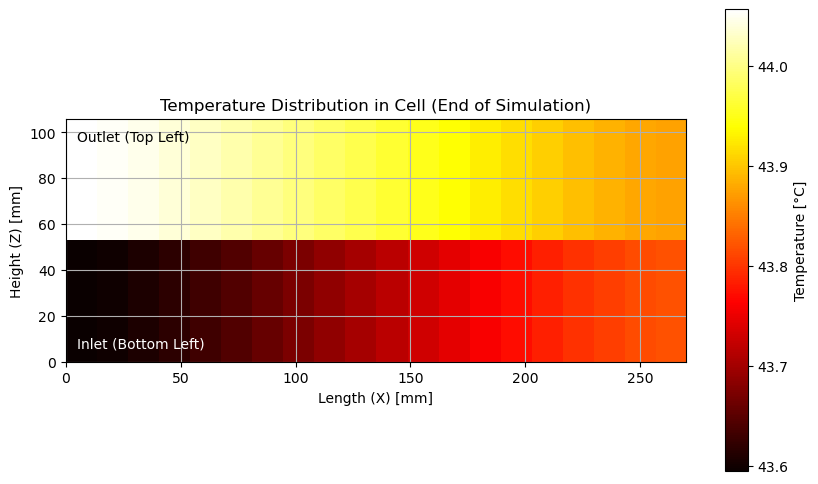

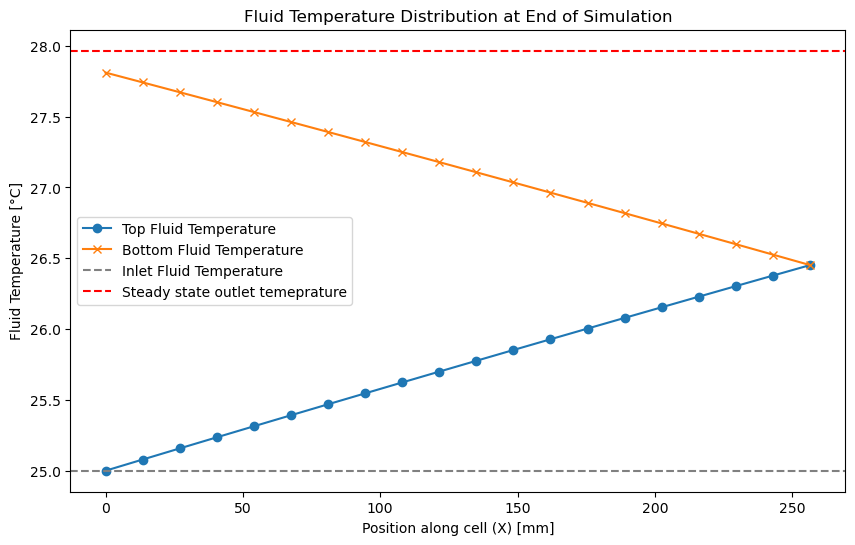

In [11]:
# --- Plot result ---
plt.figure(figsize=(10, 6))
extent = [0, length*1000, 0, height*1000]
plt.imshow(T, cmap="hot", origin="lower", extent=extent)
plt.colorbar(label="Temperature [°C]")
plt.xlabel("Length (X) [mm]")
plt.ylabel("Height (Z) [mm]")
plt.title("Temperature Distribution in Cell (End of Simulation)")
plt.grid(True)
# Annotate inlet and outlet
plt.text(5, 5, "Inlet (Bottom Left)", color="white", fontsize=10, ha="left", va="bottom")
plt.text(5, height*1000 - 5, "Outlet (Top Left)", color="black", fontsize=10, ha="left", va="top")
plt.show()

# Plot the water temperature at the end of the simulation
plt.figure(figsize=(10, 6))
plt.plot(np.arange(nx) * dx * 1000, T_fluid_top, label="Top Fluid Temperature", marker='o')
plt.plot(np.arange(nx) * dx * 1000, T_fluid_bottom, label="Bottom Fluid Temperature", marker='x')
plt.axhline(y=T_fluid_in, color='gray', linestyle='--', label="Inlet Fluid Temperature")
plt.axhline(y = T_fluid_in+Q_tot/(flow_rate * cp_fluid), color='red', linestyle='--', label="Steady state outlet temeprature")
plt.xlabel("Position along cell (X) [mm]")
plt.ylabel("Fluid Temperature [°C]")
plt.title("Fluid Temperature Distribution at End of Simulation")
plt.legend()

In [12]:
#%matplotlib notebook
import matplotlib.animation as animation
animation_flag = 0  # Set to 1 to enable animation, 0 to disable
if animation_flag == 1:
    fig, ax = plt.subplots(figsize=(10, 6))
    extent = [0, length * 1000, 0, height * 1000]  # For consistent mm scale
    im = ax.imshow(T_hist[0], cmap="hot", origin="lower", extent=extent, vmin=np.min(T_hist), vmax=np.max(T_hist))
    cbar = plt.colorbar(im, ax=ax, label="Temperature [°C]")
    ax.set_xlabel("Length (X) [mm]")
    ax.set_ylabel("Height (Z) [mm]")
    ax.set_title("Temperature Evolution in Cell")
    ax.grid(True)

    def update(frame):
        im.set_array(T_hist[frame])
        ax.set_title(f"Time: {frame*dt:.1f} s")
        return [im]

    ani = animation.FuncAnimation(fig, update, frames=nt, interval=30, blit=True)
    ani.save("temperature_evolution.mp4", writer="ffmpeg", fps=30)

In [13]:
delta_T_check = Q_tot/(flow_rate * cp_fluid)
delta_T_sim = T_fluid_bottom[0] -T_fluid_top[0]   # Check the temperature change at the outlet
print(f"Check on temperature change: {delta_T_sim:.2f} C")
print(f"Check on temperature change: {delta_T_check:.2f} C")

display(T_fluid_top)
display(T_fluid_bottom)

Check on temperature change: 2.81 C
Check on temperature change: 2.97 C


array([25.        , 25.0789081 , 25.15750258, 25.23579925, 25.31380924,
       25.39154042, 25.46899839, 25.54618721, 25.62310976, 25.69976814,
       25.7761638 , 25.85229768, 25.92817027, 26.00378158, 26.07913111,
       26.15421764, 26.22903907, 26.30359195, 26.37787093, 26.45186786])

array([27.81123097, 27.74201228, 27.67252639, 27.60277945, 27.53277518,
       27.46251573, 27.39200219, 27.32123503, 27.25021423, 27.17893948,
       27.10741023, 27.03562566, 26.96358465, 26.89128571, 26.81872674,
       26.7459048 , 26.67281564, 26.59945313, 26.52580828, 26.45186786])

In [14]:
k_y = 1 # thermal conductivity in y direction [W/m·K]
R_th_y = thickness/(dx*dz*k_y) # thermal resistance in y direction [K/W]
print(f"Thermal resistance in y direction: {R_th_y:.4f} K/W")

delta_T_y = (q_gen*dV)*R_th_y
print(q_gen*dV)
display(delta_T_y)



Thermal resistance in y direction: 34.6611 K/W
1.5000000000000002


51.9916142557652